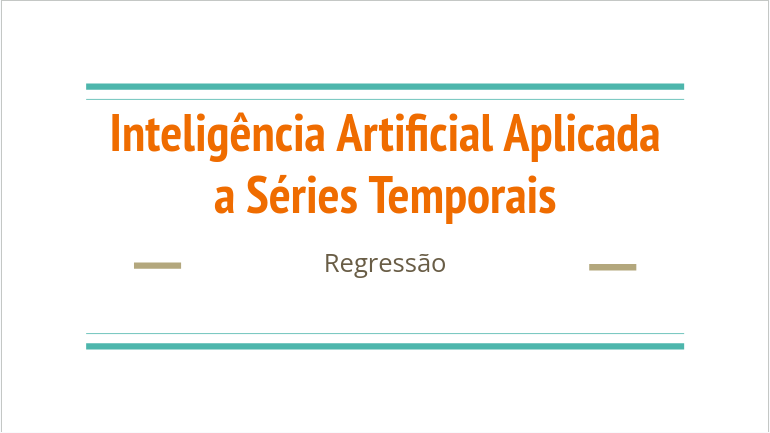

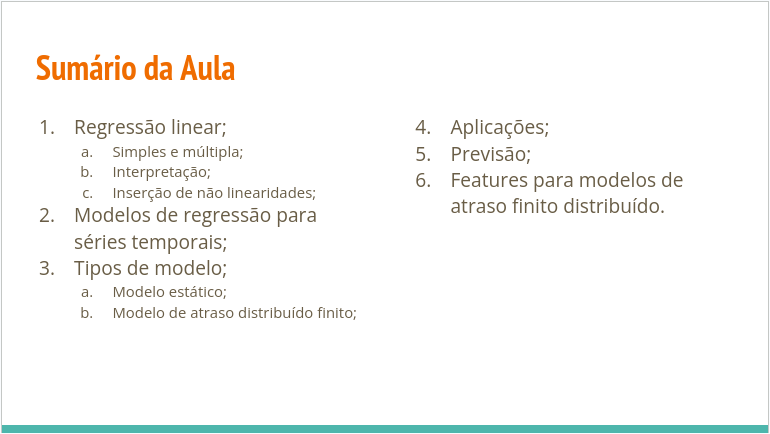

## Bibliotecas

In [ ]:
!pip install wooldridge

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import wooldridge
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Regressão linear

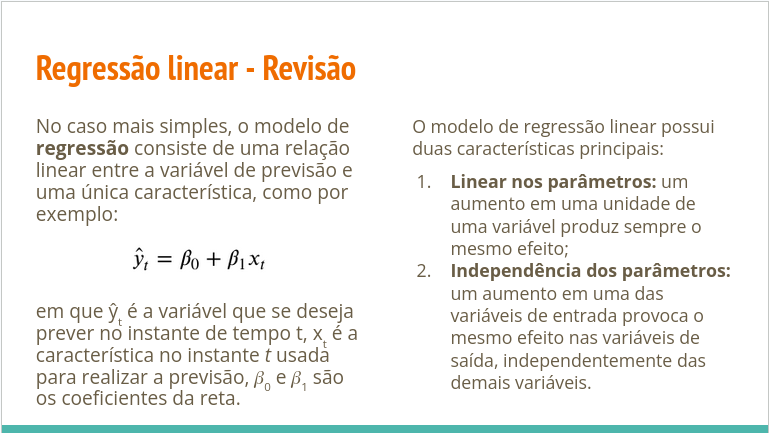

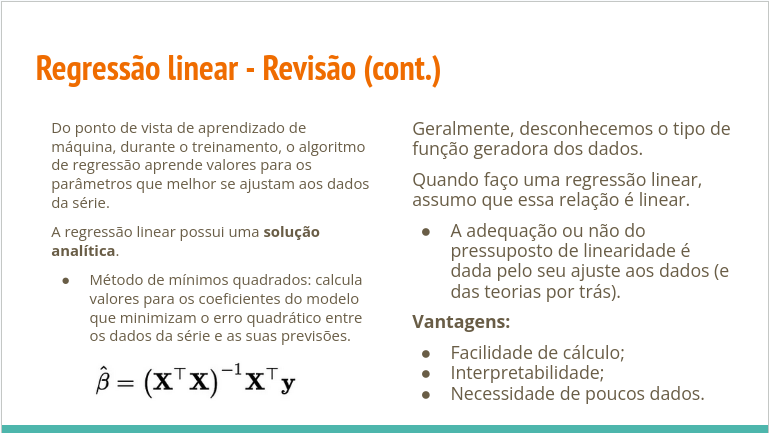

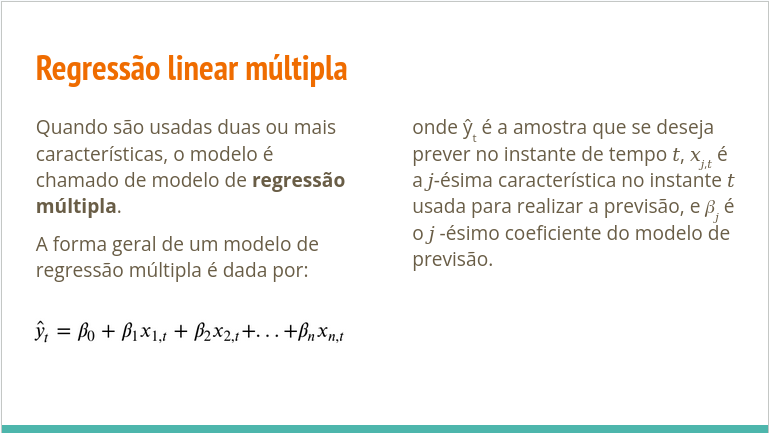

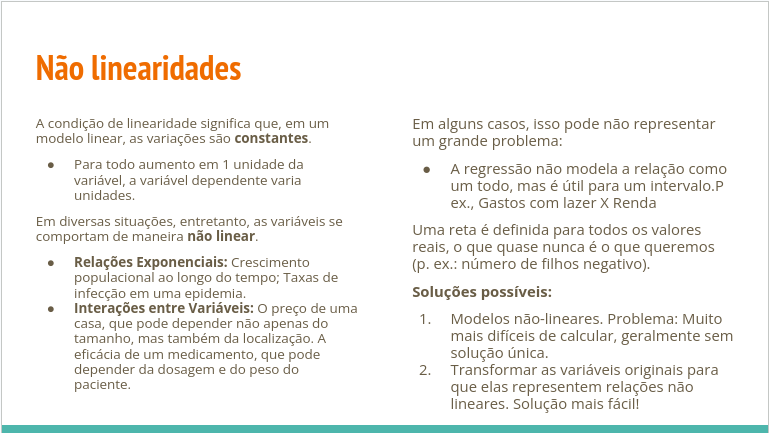

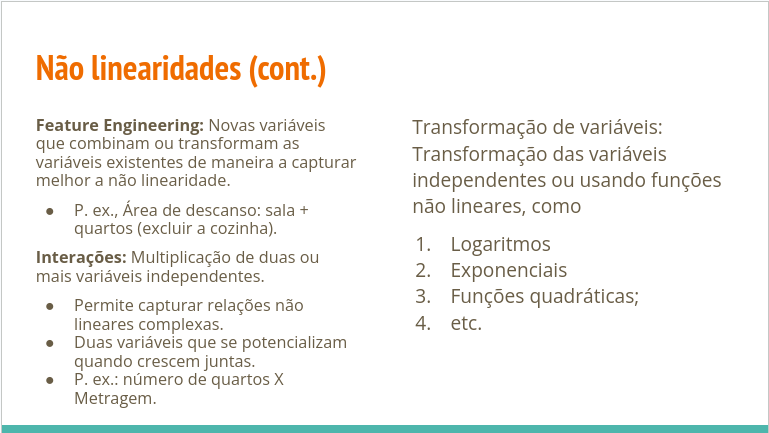

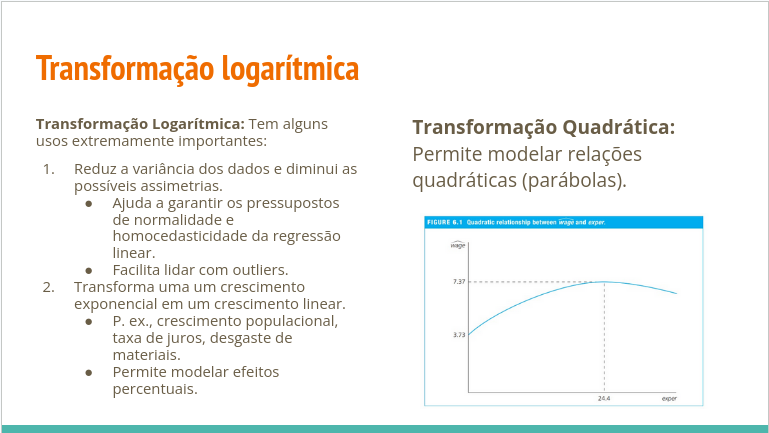

### Exemplo

Vamos pegar os dados da população na região da África Central e Sul, fornecidos pelo Banco Mundial (https://data.worldbank.org/indicator/SP.POP.TOTL?locations=XM), para realizar previsão de crescimento populacional na próxima década.

In [ ]:
ano = ["1960","1961","1962","1963","1964","1965","1966","1967","1968","1969","1970","1971","1972","1973","1974","1975","1976","1977","1978","1979","1980","1981","1982","1983","1984","1985","1986","1987","1988","1989","1990","1991","1992","1993","1994","1995","1996","1997","1998","1999","2000","2001","2002","2003","2004","2005","2006","2007","2008","2009","2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020","2021"]
africa_sul = ["130836765","134159786","137614644","141202036","144920186","148769974","152752671","156876454","161156430","165611760","170257189","175100167","180141148","185376550","190800796","196409937","202205766","208193045","214368393","220740384","227305945","234058404","240999134","248146290","255530063","263161451","271050065","279184536","287524258","296024639","304648010","313394693","322270073","331265579","340379934","349605660","358953595","368440591","378098393","387977990","398113044","408522129","419223717","430246635","441630149","453404076","465581372","478166911","491173160","504604672","518468229","532760424","547482863","562601578","578075373","593871847","609978946","626392880","643090131","660046272","677243299","694665117"]
africa_central =["96396419","98407221","100506960","102691339","104953470","107289875","109701811","112195950","114781116","117468741","120269044","123184308","126218502","129384954","132699537","136173544","139813171","143615715","147571063","151663853","155882270","160223588","164689764","169279422","173991851","178826553","183785612","188868567","194070079","199382783","204803865","210332267","215976366","221754806","227692136","233807627","240114179","246613750","253302310","260170348","267214544","274433894","281842480","289469530","297353098","305520588","313985474","322741656","331772330","341050537","350556886","360285439","370243017","380437896","390882979","401586651","412551299","423769930","435229381","446911598","458803476","470898870"]

In [ ]:
pop = np.array(africa_central).astype(float)
ano = np.array(ano).astype(float)
print('Dimensão dos dados:', ano.shape, pop.shape)

Dimensão dos dados: (62,) (62,)


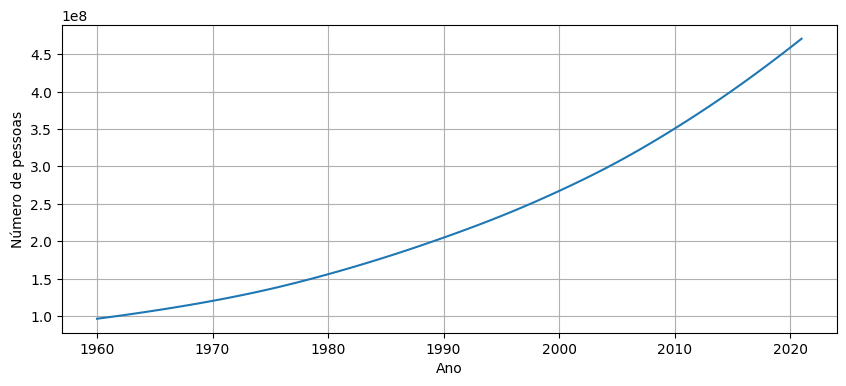

In [ ]:
# Gráfico da população versus tempo
plt.figure(figsize=(10,4))
plt.plot(ano,pop)
plt.xlabel('Ano')
plt.ylabel('Número de pessoas')
plt.grid(True)

Agora, vamos realizar uma transformação logaritimica na variável população.

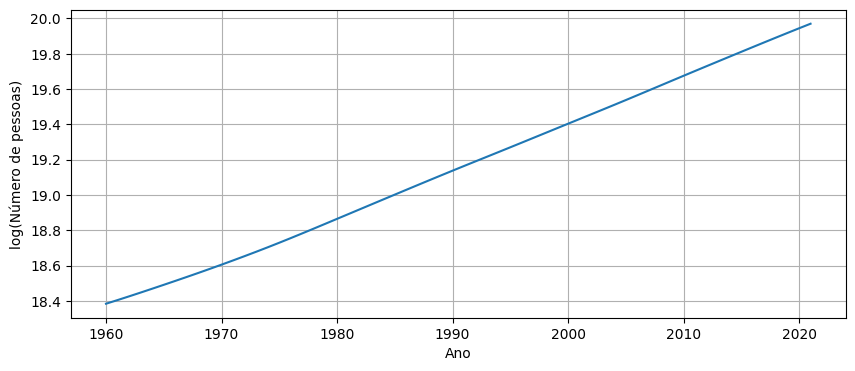

In [ ]:
# Gráfico do logaritmo natural da população versus tempo
plt.figure(figsize=(10,4))
plt.plot(ano,np.log(pop))
plt.xlabel('Ano')
plt.ylabel('log(Número de pessoas)')
plt.grid(True)

Observe que a relação população vs ano, que era exponencial, deu lugar a uma relação log(população) vs ano, que é linear.

Por ser linear, a nova relação é mais facilmente ajustada por uma regressão linear. Dessa forma, a previsão da regressão linear tende a ser mais bem-sucedida.

### Interpretação dos efeitos da regressão

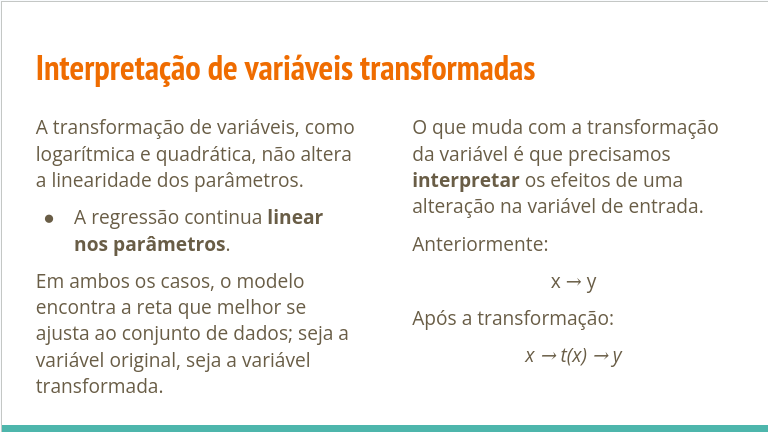

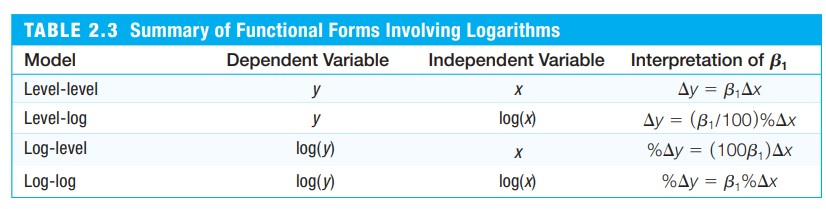

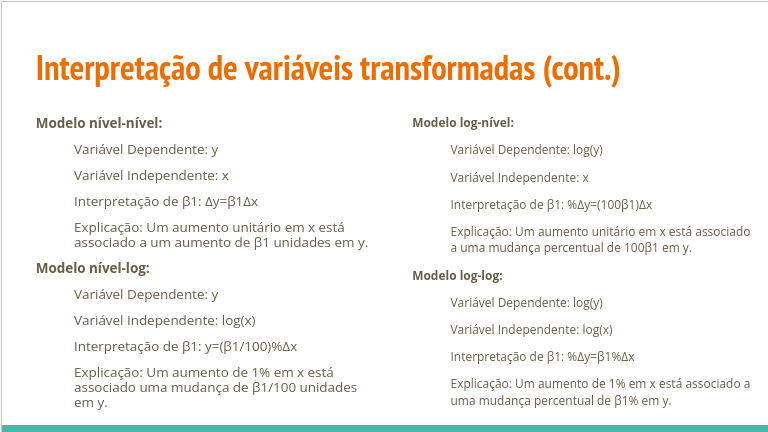

### Aplicação

O dataset 'wage' traz dados sobre 562 indivíduos no mercado de trabalho em 1976, onde salário é medido em dólares por hora. Assim, para uma pessoa em particular, se o salário for 6.75, o salário por hora é de \$6.75.

A variável 'educ' denota anos de escolaridade; por exemplo, 'educ' igual a 12 corresponde a uma educação completa de ensino médio.

In [ ]:
wage = wooldridge.data('wage1')

print(wage.shape)

wage.head()

(526, 24)


,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
0,3.10,11,2,0,0,1,0,2,1,0,...,0,0,0,0,0,0,0,1.131402,4,0
1,3.24,12,22,2,0,1,1,3,1,0,...,0,0,1,0,0,0,1,1.175573,484,4
2,3.00,11,2,0,0,0,0,2,0,0,...,0,1,0,0,0,0,0,1.098612,4,0
3,6.00,8,44,28,0,0,1,0,1,0,...,0,0,0,0,0,1,0,1.791759,1936,784
4,5.30,12,7,2,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1.667707,49,4


Vamos tentar estimar a relação entre anos de escolaridade e salário.

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='wage ~ educ',
                data=wage).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     103.4
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           2.78e-22
Time:                        00:32:55   Log-Likelihood:                -1385.7
No. Observations:                 526   AIC:                             2775.
Df Residuals:                     524   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9049      0.685     -1.321      0.1

A estimativa do coeficiente angular implica que um ano a mais de educação aumenta o salário horário por 54 centavos por hora.

O R-quadrado, porém, é de apenas 0.165, indicando que 'educ' é um preditor ruim para 'wage'. Além disso, devido à natureza linear da relação, temos que mais um ano de educação aumenta o salário pelo mesmo valor, independentemente do nível inicial de educação.

**Obs.:** O intercepto de -0,90 literalmente significa que uma pessoa sem educação tem um salário horário previsto de -0,90 dólares por hora. Isto, obviamente, não faz sentido. Isso ocorre porque apenas 18 pessoas na amostra de 526 têm menos de oito anos de educação. Consequentemente, a linha de regressão tem um desempenho ruim em níveis muito baixos de educação.

E se utilizarmos uma transformação da variável dependente ('wage')?

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='np.log(wage) ~ educ',
                data=wage).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           np.log(wage)   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     119.6
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           3.27e-25
Time:                        00:32:55   Log-Likelihood:                -359.38
No. Observations:                 526   AIC:                             722.8
Df Residuals:                     524   BIC:                             731.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5838      0.097      5.998      0.0

O coeficiente em 'educ' tem uma interpretação percentual quando é multiplicado por 100: o salário aumenta 8,3\% para cada ano adicional de educação.

Com essa transformação da variável de saída, o R-quadrado subiu para 0.186. A relação entre 'educ' e 'wage' não era, portanto, linear.

**Obs.:** a regressão acima pode não capturar toda a não-linearidade na relação entre salário e escolaridade. Se houver "efeitos de diploma", então o décimo segundo ano de educação—conclusão do ensino médio-poderia valer muito mais que o décimo primeiro ano.

## Séries temporais

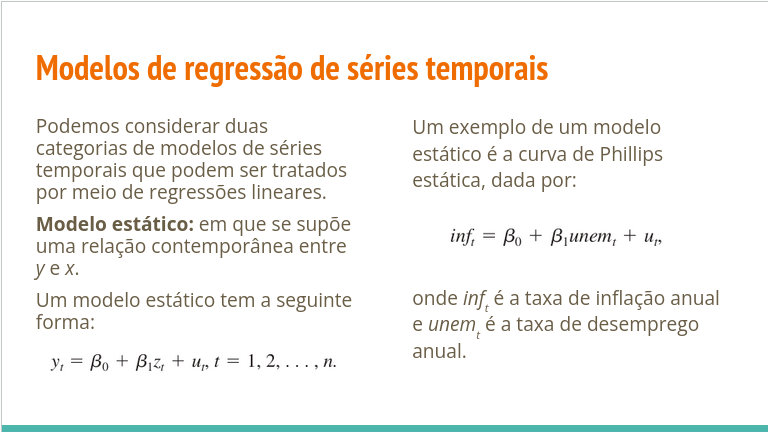

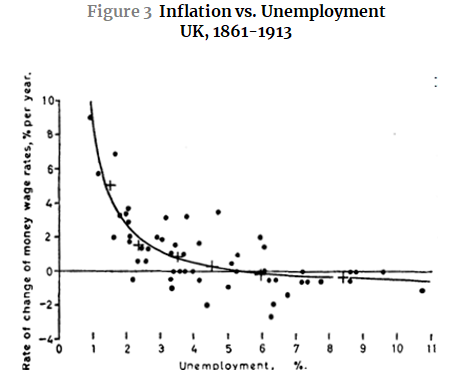

Retirado de: https://www.niskanencenter.org/is-the-phillips-curve-back-when-should-we-start-to-worry-about-inflation/

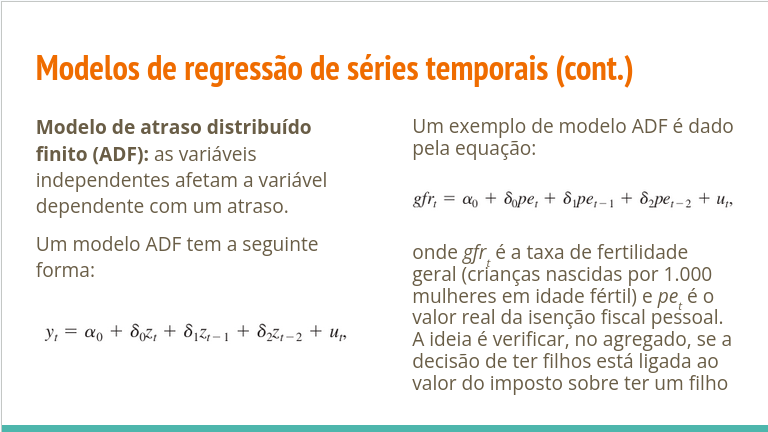

### Aplicação

Vejamos agora a aplicação de uma regressão linear utilizando essas duas categorias de modelos.

O dataset abaixo apresenta dados de natalidade para diversos indivíduos nos Estados Unidos, entre os anos de 1972 e 1984.

Referência: https://justinmshea.github.io/wooldridge/reference/fertil1.html

In [ ]:
fertil = wooldridge.data('fertil1')

print(fertil.shape)

fertil.head()

(1129, 27)


,year,educ,meduc,feduc,age,kids,black,east,northcen,west,...,y80,y82,y84,agesq,y74educ,y76educ,y78educ,y80educ,y82educ,y84educ
0,72,12,8,8,48,4,0,0,1,0,...,0,0,0,2304,0,0,0,0,0,0
1,72,17,8,18,46,3,0,0,0,0,...,0,0,0,2116,0,0,0,0,0,0
2,72,12,7,8,53,2,0,0,1,0,...,0,0,0,2809,0,0,0,0,0,0
3,72,12,12,10,42,2,0,0,1,0,...,0,0,0,1764,0,0,0,0,0,0
4,72,12,3,8,51,2,0,0,0,0,...,0,0,0,2601,0,0,0,0,0,0


Descrição das colunas:

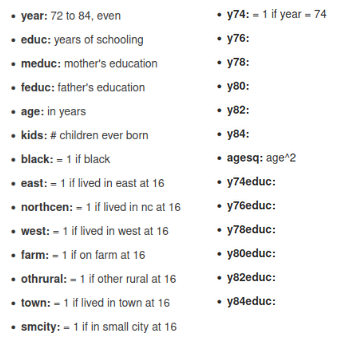

Para começar, vamos analisar se houve uma mudança substancial no número de filhos ao longo do tempo.

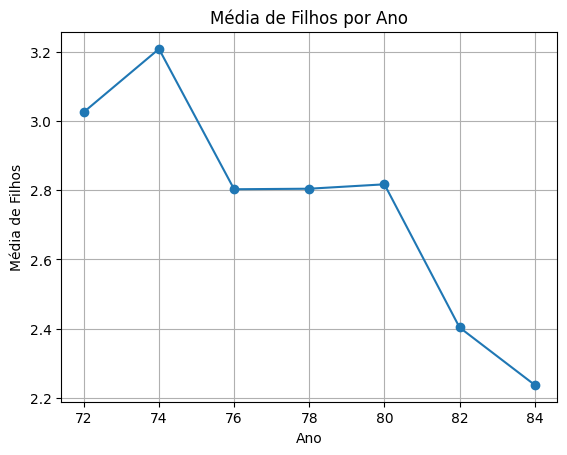

In [ ]:
# Calculando a média de filhos por ano
media_filhos_por_ano = fertil.groupby('year')['kids'].mean()

# Plotando o gráfico de linha
media_filhos_por_ano.plot(kind='line', marker='o')  # Adiciona marcadores para cada ponto de dados
plt.title('Média de Filhos por Ano')
plt.xlabel('Ano')
plt.ylabel('Média de Filhos')
plt.grid(True)  # Adiciona uma grade para facilitar a visualização

Estatísticas descritivas

In [ ]:
fertil.describe()

,year,educ,meduc,feduc,age,kids,black,east,northcen,west,...,y80,y82,y84,agesq,y74educ,y76educ,y78educ,y80educ,y82educ,y84educ
count,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,...,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000
mean,78.139947,12.690877,9.131975,9.715678,43.484500,2.743136,0.085031,0.248893,0.319752,0.108060,...,0.125775,0.164748,0.156776,1924.935341,1.884854,1.646590,1.601417,1.620018,2.178919,2.079717
std,4.091798,2.640236,4.016956,3.495150,5.836421,1.653899,0.279051,0.432563,0.466587,0.310594,...,0.331743,0.371117,0.363750,515.856380,4.534055,4.296006,4.297310,4.392529,5.030568,4.936011
min,72.000000,0.000000,0.000000,0.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1225.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,12.000000,7.000000,8.000000,38.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1444.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,78.000000,12.000000,8.000000,10.000000,43.000000,3.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1849.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,82.000000,14.000000,12.000000,12.000000,48.000000,4.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,2304.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,20.000000,20.000000,20.000000,54.000000,7.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,2916.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000


O que explica essa variação ao longo do tempo?

**1. Modelo estático**

Variáveis inicias: age, educ, meduc, feduc, black, town

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='kids ~ age + educ + meduc + feduc + black + town + farm',
                data=fertil).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   kids   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     13.84
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           2.82e-17
Time:                        00:32:56   Log-Likelihood:                -2122.7
No. Observations:                1129   AIC:                             4261.
Df Residuals:                    1121   BIC:                             4302.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3807      0.456      7.421      0.0

**Pergunta:** Como interpretar esse sumário? Quais variáveis são estatisticamente significativas? Qual o efeito de cada uma delas?

Nosso modelo não desconsidera, porém, variações ao longo dos anos (linear no parâmetro year). E se tratarmos o ano como uma variável dummy?

In [ ]:
fertil.columns

Index(['year', 'educ', 'meduc', 'feduc', 'age', 'kids', 'black', 'east',
       'northcen', 'west', 'farm', 'othrural', 'town', 'smcity', 'y74', 'y76',
       'y78', 'y80', 'y82', 'y84', 'agesq', 'y74educ', 'y76educ', 'y78educ',
       'y80educ', 'y82educ', 'y84educ'],
      dtype='object')

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='kids ~ age + educ + meduc + feduc + black + town + y74 + y76 + y78 + y80 + y82 + y84',
                data=fertil).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   kids   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     11.19
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           2.14e-21
Time:                        00:32:56   Log-Likelihood:                -2105.4
No. Observations:                1129   AIC:                             4237.
Df Residuals:                    1116   BIC:                             4302.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.5057      0.467      7.510      0.0

**Conclusão:** Embora não tenha havido grandes ganhos com a inserção das variáveis dummy, há um efeito claro de uma pessoa ter nascido em 1984 ou 1982, em relação a 1972, para o número de filhos. Controlando para idade, educação, etc., mulheres nascidas em 1984 tem cerca de 0.57 filhos a menos do que mulheres com as mesmas características nascidas em 1972.

**2. Modelo de atraso distribuído finito**

Nesse segundo exemplo, vamos tentar explicar a inflação nos EUA a partir de dados macroeconômicos.

Referência: https://justinmshea.github.io/wooldridge/reference/intdef.html

In [ ]:
intdef = wooldridge.data('intdef')

print(intdef.shape)

intdef.head()

(56, 13)


,year,i3,inf,rec,out,def,i3_1,inf_1,def_1,ci3,cinf,cdef,y77
0,1948,1.04,8.1,16.200001,11.6,-4.600000,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1949,1.10,-1.2,14.500000,14.3,-0.200000,1.04,8.1,-4.600000,0.06,-9.3,4.400001,0
2,1950,1.22,1.3,14.400000,15.6,1.200001,1.10,-1.2,-0.200000,0.12,2.5,1.400001,0
3,1951,1.55,7.9,16.100000,14.2,-1.900001,1.22,1.3,1.200001,0.33,6.6,-3.100001,0
4,1952,1.77,1.9,19.000000,19.4,0.400000,1.55,7.9,-1.900001,0.22,-6.0,2.300000,0


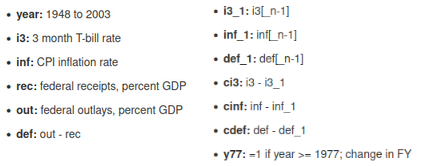

In [ ]:
intdef['time'] = range(len(intdef))

Estatísticas descritivas

In [ ]:
intdef.describe()

,year,i3,inf,rec,out,def,i3_1,inf_1,def_1,ci3,cinf,cdef,y77,time
count,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,56.000000,56.000000
mean,1975.500000,4.908214,3.883929,17.923214,19.525000,1.601786,4.978909,3.912727,1.569091,-0.000364,-0.105455,0.145455,0.482143,27.500000
std,16.309506,2.868242,3.040381,1.202723,2.308266,2.109415,2.845014,3.060686,2.114489,1.367487,2.414034,1.506384,0.504203,16.309506
min,1948.000000,0.950000,-1.200000,14.400000,11.600000,-4.600000,0.950000,-1.200000,-4.600000,-3.340000,-9.300000,-3.200001,0.000000,0.000000
25%,1961.750000,2.892500,1.675000,17.475000,18.575000,0.300001,2.975000,1.650000,0.300000,-0.605000,-1.150000,-0.850000,0.000000,13.750000
50%,1975.500000,4.735000,3.050000,17.799999,19.450000,1.450000,4.810000,3.100000,1.400000,0.120000,0.200000,0.099998,0.000000,27.500000
75%,1989.250000,6.515000,5.425000,18.500000,21.225000,2.950001,6.570000,5.450000,2.900001,0.920000,1.100000,1.200000,1.000000,41.250000
max,2003.000000,14.030000,13.500000,20.900000,23.500000,6.100000,14.030000,13.500000,6.100000,2.970000,6.600000,4.400001,1.000000,55.000000


Vamos comparar uma série de modelos preditivos. Para isso, vamos separar os conjuntos treinamento e teste.

In [ ]:
# O programa não aceitava uma variável com nome def
intdef.rename(columns={'def': 'deficit'}, inplace=True)

Por exemplo, há uma relação entre déficit do governo e inflação?

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='I(inf) ~ deficit',
                data=intdef).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 I(inf)   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.5179
Date:                Fri, 25 Oct 2024   Prob (F-statistic):              0.475
Time:                        00:32:56   Log-Likelihood:                -140.96
No. Observations:                  56   AIC:                             285.9
Df Residuals:                      54   BIC:                             290.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.6589      0.514      7.117      0.0

Faz sentido que não haja grande relação entre as duas variáveis: o déficit costuma demorar para gerar um efeito no aumento na inflação. Além disso, não é óbvio que vamos ter os dados do déficit antes dos dados da inflação, o que pode tornar esse modelo inútil na prática.

 E se ajustássemos para o déficit do ano anterior?

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='I(inf) ~ def_1',
                data=intdef).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 I(inf)   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     4.663
Date:                Fri, 25 Oct 2024   Prob (F-statistic):             0.0354
Time:                        00:32:56   Log-Likelihood:                -135.88
No. Observations:                  55   AIC:                             275.8
Df Residuals:                      53   BIC:                             279.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.1714      0.491      6.456      0.0

O resultado é semelhante, num cenário mais factível: prever a inflação de um ano a partir do déficit do governo do ano anterior.

Nesse caso, incluir a variável déficit (contemporâneo) não traz novos ganhos.

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='I(inf) ~ deficit + def_1',
                data=intdef).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 I(inf)   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     2.302
Date:                Fri, 25 Oct 2024   Prob (F-statistic):              0.110
Time:                        00:32:56   Log-Likelihood:                -135.87
No. Observations:                  55   AIC:                             277.7
Df Residuals:                      52   BIC:                             283.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.2038      0.534      6.002      0.0

E qual o papel da taxa de juros? Vamos fazer uma regressão agora utilizando a taxa de juros de 3 meses do ano anterior.

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='I(inf) ~ i3_1',
                data=intdef).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 I(inf)   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     32.19
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           5.96e-07
Time:                        00:32:56   Log-Likelihood:                -125.15
No. Observations:                  55   AIC:                             254.3
Df Residuals:                      53   BIC:                             258.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5658      0.657      0.862      0.3

A taxa de juros dos títulos de 3 meses é um preditor muito melhor que o déficit do governo. De fato, nesse caso, incluir o déficit anterior não traz qualquer ganho.

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='I(inf) ~ def_1 + i3_1',
                data=intdef).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 I(inf)   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     15.79
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           4.37e-06
Time:                        00:32:56   Log-Likelihood:                -125.15
No. Observations:                  55   AIC:                             256.3
Df Residuals:                      52   BIC:                             262.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5637      0.664      0.850      0.3

O ajuste não teve uma melhora significativa. Muito provavalmente, tanto a inflação do ano t quanto a taxa de juros do ano t são causadas por outro fator: a inflação do ano anterior.

**3. Modelos mistos**

Vamos considear um deslocamento da variável de interesse.

In [ ]:
#O dataset já inclui a variável inflação deslocada, mas precisámos, poderíamos criá-la com o código abaixo

#intdef['inf_1'] = intdef['inf'].shift(1)

#intdef.head()

Usando apenas a inflação do ano anterior como previsor, obtemos:

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='I(inf) ~ inf_1',
                data=intdef).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 I(inf)   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     46.65
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           8.48e-09
Time:                        00:32:56   Log-Likelihood:                -120.84
No. Observations:                  55   AIC:                             245.7
Df Residuals:                      53   BIC:                             249.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1717      0.488      2.400      0.0

A inclusão da inflação do ano anterior melhora consideravalmente o ajuste do modelo.

Acrescentando outras variáveis

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='I(inf) ~ i3_1 + def_1 + inf_1',
                data=intdef).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 I(inf)   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     18.74
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           2.52e-08
Time:                        00:32:56   Log-Likelihood:                -117.77
No. Observations:                  55   AIC:                             243.5
Df Residuals:                      51   BIC:                             251.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4535      0.587      0.773      0.4

O déficit e a taxa de juros do ano anterior também ajudam a prever a inflação do próximo ano.

#### Exercício

Construa um modelo que inclua variáveis com deslocamento maior que 1 ano.

**Observação:** Em geral, para um deslocamento de *n* passos, precisamos eliminar as primeiras *n* observações do conjunto treinamento.

In [ ]:
intdef['inf_2'] = intdef['inf'].shift(2)
intdef['inf_3'] = intdef['inf'].shift(3)

# Fazendo a regressão
model = smf.ols(formula='I(inf) ~ inf_1 + inf_2 + np.log(inf_3)',
                data=intdef).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 I(inf)   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     46.73
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           3.80e-14
Time:                        00:32:57   Log-Likelihood:                -92.772
No. Observations:                  51   AIC:                             193.5
Df Residuals:                      47   BIC:                             201.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.7145      0.423      1.687

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Previsões

Até agora, consideramos a capacidade de nosso modelo explicar a variação nos dados. Essa tarefa é muito importante, e utilizada com frequência em várias áreas, em particular nas ciências sociais.

Muitas vezes, contudo, estamos interessado em encontrar um modelo que generalize para novos dados. Ou seja, que faça **previsões para o futuro**.

O dataset utilizado apresenta informações sobre número de passageiros, para várias linhas de voo.

**Referência:** https://justinmshea.github.io/wooldridge/reference/airfare.html

In [ ]:
airfare = wooldridge.data('airfare')

print(airfare.shape)

airfare.head()

(4596, 14)


,year,id,dist,passen,fare,bmktshr,ldist,y98,y99,y00,lfare,ldistsq,concen,lpassen
0,1997,1,528,152,106,0.8386,6.269096,0,0,0,4.663439,39.301571,0.8386,5.023880
1,1998,1,528,265,106,0.8133,6.269096,1,0,0,4.663439,39.301571,0.8133,5.579730
2,1999,1,528,336,113,0.8262,6.269096,0,1,0,4.727388,39.301571,0.8262,5.817111
3,2000,1,528,298,123,0.8612,6.269096,0,0,1,4.812184,39.301571,0.8612,5.697093
4,1997,2,861,282,104,0.5798,6.758094,0,0,0,4.644391,45.671837,0.5798,5.641907


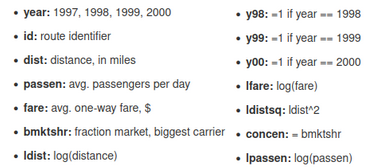

In [ ]:
airfare.describe()

,year,id,dist,passen,fare,bmktshr,ldist,y98,y99,y00,lfare,ldistsq,concen,lpassen
count,4596.000000,4596.000000,4596.000000,4596.000000,4596.000000,4596.000000,4596.000000,4596.00000,4596.00000,4596.00000,4596.000000,4596.000000,4596.000000,4596.000000
mean,1998.500000,575.000000,989.744996,636.824195,178.796780,0.610115,6.696482,0.25000,0.25000,0.25000,5.095601,45.277471,0.610115,6.017027
std,1.118156,331.723694,611.831506,811.999966,74.881513,0.196435,0.659318,0.43306,0.43306,0.43306,0.436400,8.726898,0.196435,0.883987
min,1997.000000,1.000000,95.000000,2.000000,37.000000,0.160500,4.553877,0.00000,0.00000,0.00000,3.610918,20.737795,0.160500,0.693147
25%,1997.750000,288.000000,505.000000,215.000000,123.000000,0.465000,6.224558,0.00000,0.00000,0.00000,4.812184,38.745125,0.465000,5.370638
50%,1998.500000,575.000000,861.000000,357.000000,168.000000,0.603950,6.758094,0.00000,0.00000,0.00000,5.123964,45.671837,0.603950,5.877736
75%,1999.250000,862.000000,1304.000000,717.000000,225.000000,0.753100,7.173192,0.25000,0.25000,0.25000,5.416101,51.454678,0.753100,6.575076
max,2000.000000,1149.000000,2724.000000,8497.000000,522.000000,1.000000,7.909857,1.00000,1.00000,1.00000,6.257668,62.565834,1.000000,9.047468


Para começar, vamos dividir nosso conjunto de dados em treinamento e teste.

In [ ]:
# Anos reportados
airfare['year'].unique()

array([1997, 1998, 1999, 2000])

Precisamos, primeiro, criar uma variável com o número de passageiros do ano anterior, para cada ID (linha aérea).

In [ ]:
# Primeiro, certifique-se de que os dados estão ordenados corretamente
airfare.sort_values(['id', 'year'], inplace=True)

# Agrupar por 'id' e criar a nova coluna 'fare-1'
airfare['passen_1'] = airfare.groupby('id')['passen'].shift(1)

airfare.head()

,year,id,dist,passen,fare,bmktshr,ldist,y98,y99,y00,lfare,ldistsq,concen,lpassen,passen_1
0,1997,1,528,152,106,0.8386,6.269096,0,0,0,4.663439,39.301571,0.8386,5.023880,NaN
1,1998,1,528,265,106,0.8133,6.269096,1,0,0,4.663439,39.301571,0.8133,5.579730,152.0
2,1999,1,528,336,113,0.8262,6.269096,0,1,0,4.727388,39.301571,0.8262,5.817111,265.0
3,2000,1,528,298,123,0.8612,6.269096,0,0,1,4.812184,39.301571,0.8612,5.697093,336.0
4,1997,2,861,282,104,0.5798,6.758094,0,0,0,4.644391,45.671837,0.5798,5.641907,NaN


Partição do conjunto de dados:

In [ ]:
train = airfare.loc[airfare['year'] != 2000]
test = airfare.loc[airfare['year'] == 2000]

print('Train size:', len(train))
print('Test size:', len(test))

Train size: 3447
Test size: 1149


Como métrica de erro, utilizaremos o **erro quadrático médio** e o **erro médio absoluto percentual.**

Nosso modelo terá as seguintes variáveis:

1. Custo (fare);
2. Distância (nível e quadrática);
3. Número de passageiros do ano anterior;
4. Ano.

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='passen ~ passen_1',
                data=train).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 passen   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.290e+05
Date:                Fri, 25 Oct 2024   Prob (F-statistic):               0.00
Time:                        00:32:57   Log-Likelihood:                -14021.
No. Observations:                2298   AIC:                         2.805e+04
Df Residuals:                    2296   BIC:                         2.806e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.7354      2.865      0.955      0.3

O R-quadrado do nosso modelo é bastante alto, segerindo que as linhas de aviação têm um número bastante estável de passageiros. Esse modelo é o **modelo base** que vimos na aula anterior.

In [ ]:
# Função para calcular o erro médio absoluto porcentual (MAEP)
def mean_absolute_percentage_error(y_true, y_pred):
  return np.mean(np.abs((y_true - y_pred) / np.mean(y_true))) * 100

In [ ]:
pred_lr = model.predict(test)

lr_quadratic_error = mean_squared_error(test['passen'], pred_lr)
lr_percentage_error = mean_absolute_percentage_error(test['passen'], pred_lr)
lr_R2 = r2_score(test['passen'], pred_lr)

print(f'Erro quadrático médio para a regressão linear: {lr_quadratic_error:.2f}')
print(f'Erro médio absoluto porcentual para a regressão linear: {lr_percentage_error:.2f}')
print(f'R-quadrado para a regressão linear: {lr_R2:.2f}')

Erro quadrático médio para a regressão linear: 20013.12
Erro médio absoluto porcentual para a regressão linear: 10.26
R-quadrado para a regressão linear: 0.97


**Conclusão:** O modelo tem um ajuste muito alto. O erro médio quadrático é alto porque os valores originais são grandes: o erro segue a mesma escala de valores. Nesse sentido, o erro médio absoluto porcentual pode fornecer um valor mais razoável. Para facilitar, vamos focar só no erro médio absoluto porcentual.

De toda forma, o que interessa em geral não são os erros em sentido abosluto, mas a diferença entre as diferentes modelagens.

### Modelo base

In [ ]:
# Para o conjunto treinamento
train_base = train.dropna()

base_error = mean_absolute_percentage_error(train_base['passen'], train_base['passen_1'])
base_R2 = r2_score(train_base['passen'], train_base['passen_1'])

print(f'Erro médio absoluto porcentual para o modelo base: {base_error:.2f}')
print(f'R-quadrado para o modelo base: {base_R2:.2f}')

Erro médio absoluto porcentual para o modelo base: 9.79
R-quadrado para o modelo base: 0.98


In [ ]:
# Para o conjunto test
base_error = mean_absolute_percentage_error(test['passen'], test['passen_1'])
base_R2 = r2_score(test['passen'], test['passen_1'])

print(f'Erro médio absoluto porcentual para o modelo base: {base_error:.2f}')
print(f'R-quadrado para o modelo base: {base_R2:.2f}')

Erro médio absoluto porcentual para o modelo base: 9.77
R-quadrado para o modelo base: 0.97


### Modelo de tendência simples

Para o modelo de tendência, vou calcular a média de passageiros por ID para os anos no conjunto treinamento. Este valor será a tendência para o nosso modelo.

**Importante:** precisamos calcular a tendência a partir do conjunto de treinamento, senão nosso modelo estará utilizando informações do conjunto teste para fazer a previsão.

In [ ]:
## Calcular a tendência no conjunto treinamento
# Filtrar os anos 1997 e 1999 no conjunto de treinamento
train_1997 = train[train['year'] == 1997][['id', 'passen']].rename(columns={'passen': 'passen_1997'})
train_1999 = train[train['year'] == 1999][['id', 'passen']].rename(columns={'passen': 'passen_1999'})

# Fazer merge dos dados de 1997 e 1999 com base em 'id'
train_trend = pd.merge(train_1997, train_1999, on='id')

# Calcular a diferença e dividir por 3 (a diferença anual)
train_trend['trend_increment'] = (train_trend['passen_1999'] - train_trend['passen_1997']) / 3

In [ ]:
# Previsão para o conjunto de teste (ano 2000), somando a diferença ao valor de 1999
test = pd.merge(test, train_trend[['id', 'passen_1999', 'trend_increment']], on='id', how='left')

# Aplicar a fórmula: previsão = passen_1999 + trend_increment
test['trend'] = test['passen_1999'] + test['trend_increment']

# Verificar se o conjunto de teste tem valores suficientes após as operações
test_na = test.dropna(subset=['passen', 'trend'])

trend_error_test = mean_absolute_percentage_error(test_na['passen'], test_na['trend'])
trend_R2_test = r2_score(test_na['passen'], test_na['trend'])

print(f'Erro médio absoluto porcentual para modelo de tendência (teste): {trend_error_test:.2f}')
print(f'R-quadrado para modelo de tendência (teste): {trend_R2_test:.2f}')

Erro médio absoluto porcentual para modelo de tendência (teste): 10.81
R-quadrado para modelo de tendência (teste): 0.97


O resultado do modelo de tendência ficou ligeiramente pior que o do modelo base.

É difícil pensar num modelo de sazonalidade nesse caso, então não vamos considerar esse modelo.

## Features

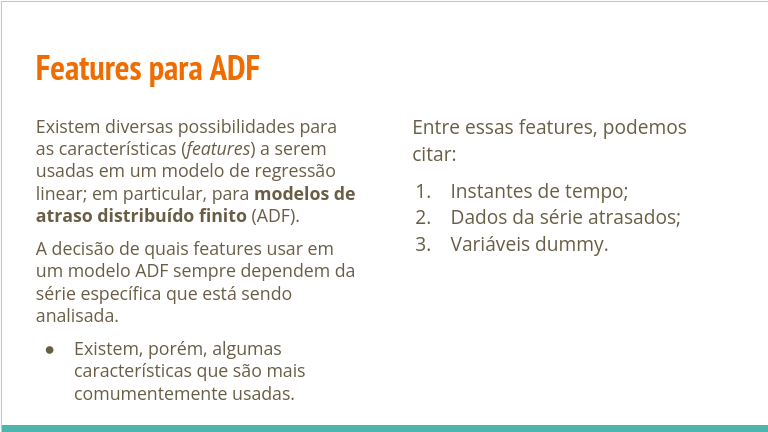

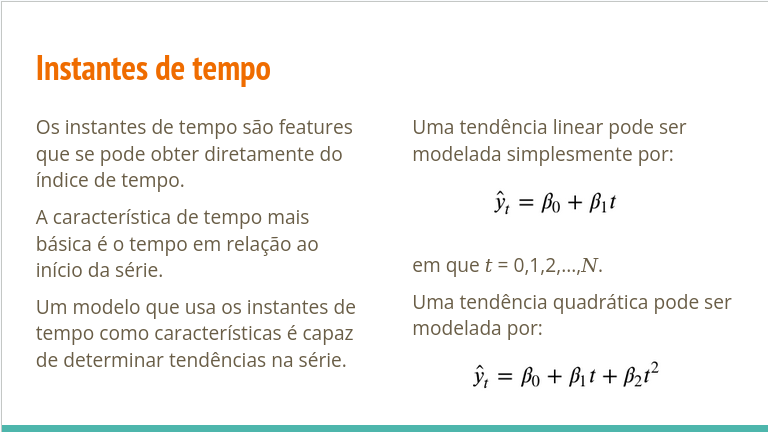

### Aplicação: Tendência linear

Vamos usar a série de "Milk Production" do Kaggle (https://www.kaggle.com/code/naffyy/milk-production-data) para calcular a tendência dessa série.

In [ ]:
# carrega dados em um dataframe pandas
df_milk = pd.read_csv('monthlyMilkProduction.csv')
print('Dimensão dos dados:', df_milk.shape)

df_milk.head()

Dimensão dos dados: (169, 2)


,Month,Production
0,1962-01,589.0
1,1962-02,561.0
2,1962-03,640.0
3,1962-04,656.0
4,1962-05,727.0


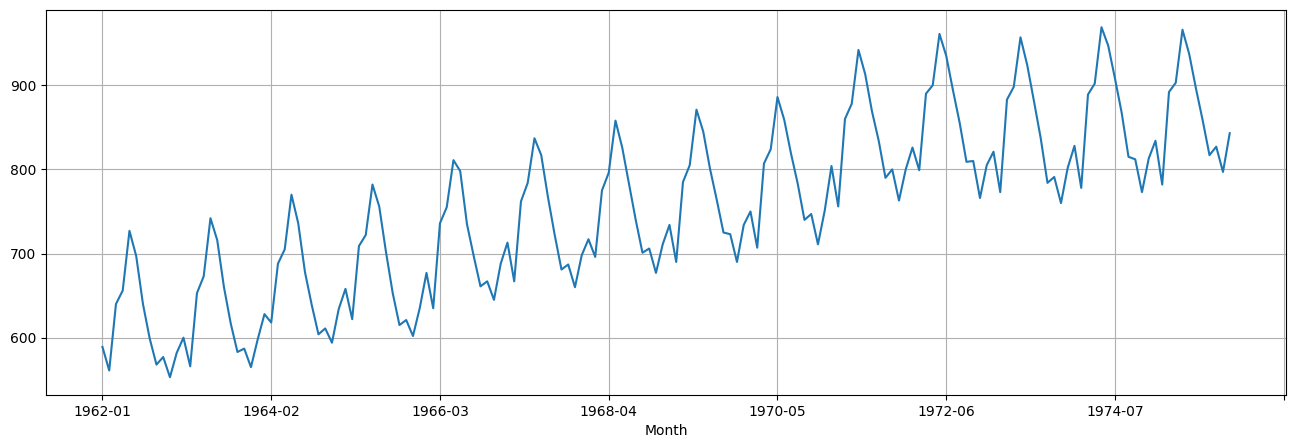

In [ ]:
# Separa coluna da data-hora
date_time = df_milk.pop('Month')#, format='%d.%m.%Y %H:%M:%S')

plot_features = df_milk['Production']
plot_features.index = date_time
_ = plot_features.plot(subplots=True, figsize = (16,5))
plt.grid(True)
plt.show()

In [ ]:
# Elimina último dado que é NaN
df_milk = df_milk.iloc[1:-1]

Para começar, vamos fazer uma regressão linear com o tempo como a variável de entrada.

In [ ]:
# Vamos criar uma variável com os instantes de tempo
df_milk['time'] = range(len(df_milk))

df_milk.head()

<ipython-input-95-b34e518340db>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_milk['time'] = range(len(df_milk))


,Production,time
1,561.0,0
2,640.0,1
3,656.0,2
4,727.0,3
5,697.0,4


In [ ]:
# Fazendo a regressão
model = smf.ols(formula='Production ~ time',
                data=df_milk).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Production   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     298.0
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           8.30e-39
Time:                        00:32:58   Log-Likelihood:                -922.18
No. Observations:                 167   AIC:                             1848.
Df Residuals:                     165   BIC:                             1855.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    615.6514      9.382     65.620      0.0

O modelo linear apresenta um bom ajuste, o que indica a tendência linear de crescimento ao longo do tempo.

### Aplicação: Valores atrasados da série

Vamos criar agora um modelo baseado em valores passados para essa série.
Essa série apresenta uma sazonalidade de 1 ano. Portanto, é natural pensarmos em usar os valores mensais de 12 meses anteriores como features.

Vamos criar um novo dataframe com novas colunas, sendo que cada nova coluna representa um valor atrasado da série. Para isso, usaremos a função 'shift' do pandas.

O modelo que vamos usar é o seguinte:

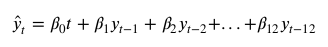

In [ ]:
# Adiciona o componente sazonal (12 períodos)
df_milk['seasonal'] = df_milk['Production'].shift(12)

# Adiciona componente de tendência
window = 3
df_milk['trend'] = df_milk['Production'].rolling(window=window).mean()

df_milk

<ipython-input-97-02b3aa9f9348>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_milk['seasonal'] = df_milk['Production'].shift(12)


,Production,time,seasonal,trend
1,561.0,0,NaN,NaN
2,640.0,1,NaN,NaN
3,656.0,2,NaN,619.000000
4,727.0,3,NaN,674.333333
5,697.0,4,NaN,693.333333
...,...,...,...,...
163,858.0,162,867.0,897.000000
164,817.0,163,815.0,857.000000
165,827.0,164,812.0,834.000000
166,797.0,165,773.0,813.666667


As 12 primeiras linhas apresentam valores ausentes e, portanto, precisam ser retiradas antes de fazermos o ajuste do modelo.

In [ ]:
df_milk = df_milk.dropna()

Para ajustar os coeficientes do modelo, no lugar de usar o GradientTape como fizemos no exemplo anterior, vamos usar o método minimize da classe de otimizadores do TensorFlow.

In [ ]:
# Fazendo a regressão
model = smf.ols(formula='Production ~ seasonal + trend',
                data=df_milk).fit()

# Criando um sumário dos resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Production   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     3009.
Date:                Fri, 25 Oct 2024   Prob (F-statistic):          5.72e-123
Time:                        00:32:58   Log-Likelihood:                -640.61
No. Observations:                 155   AIC:                             1287.
Df Residuals:                     152   BIC:                             1296.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.6134     10.260      3.374      0.0

In [ ]:
# Calcula previsões com o modelo ajustado
df_milk['predicted_production'] = model.predict(df_milk[['seasonal', 'trend']])

df_milk.head()

<ipython-input-100-f7328138b45e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_milk['predicted_production'] = model.predict(df_milk[['seasonal', 'trend']])


,Production,time,seasonal,trend,predicted_production
13,566.0,12,561.0,582.666667,585.272656
14,653.0,13,640.0,606.333333,653.584827
15,673.0,14,656.0,630.666667,670.509850
16,742.0,15,727.0,689.333333,737.817426
17,716.0,16,697.0,710.333333,716.617645


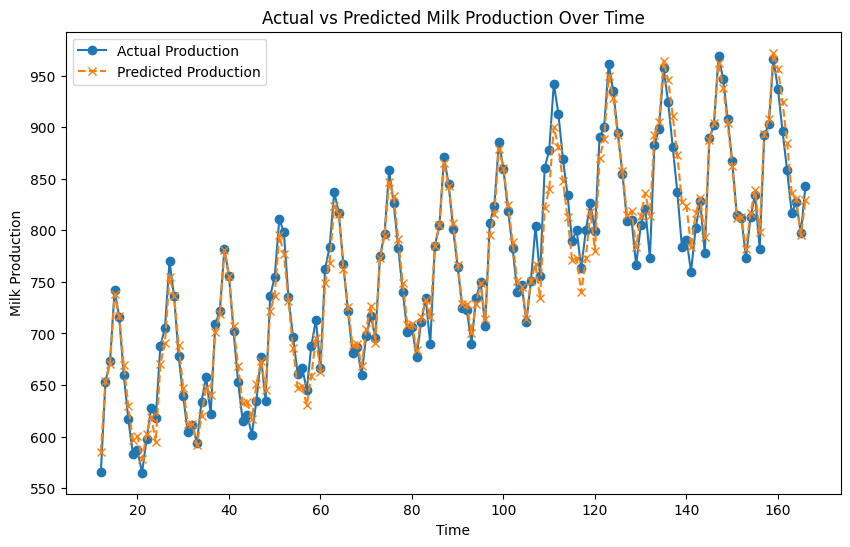

In [ ]:
# Gráfico comparando valores previstos e reais
plt.figure(figsize=(10, 6))
plt.plot(df_milk['time'], df_milk['Production'], label='Actual Production', marker='o')
plt.plot(df_milk['time'], df_milk['predicted_production'], label='Predicted Production', linestyle='--', marker='x')

plt.xlabel('Time')
plt.ylabel('Milk Production')
plt.title('Actual vs Predicted Milk Production Over Time')
plt.legend()

### Variáveis dummy

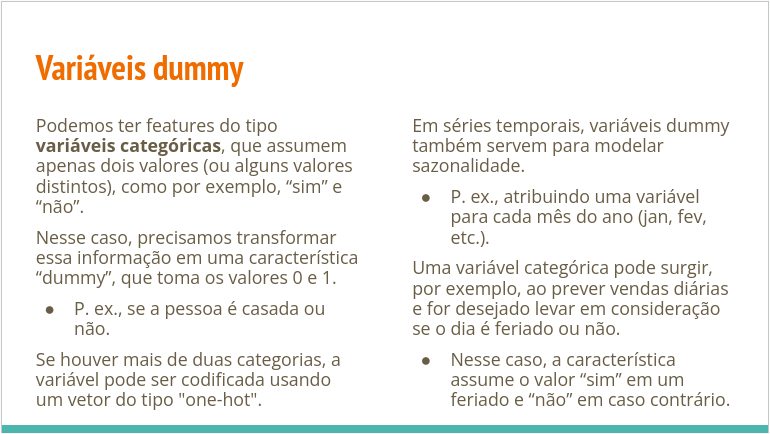

## Exercício

Na aula anterior, começamos a trabalhar com um conjunto de dados de vendas de imóveis. Esse dataset apresenta valores e características de imóveis vendidos entre 2007 e 2019, e foi retirado do [Kaggle](https://www.kaggle.com/datasets/htagholdings/property-sales) [ma_lga_12345.csv].

Calcula o erro médio absoluto percentual para os modelos de previsão de série que vimos na aula anterior:

*   Base
*   Sazonal
*   Tendência
*   Média móvel

Utilize também um modelo de regressão linear, que faça uso dos valores anteriores  da série e das propriedades do imóvel.

In [ ]:
data = pd.read_csv('ma_lga_12345.csv')

# Convertendo a coluna 'saledate' para o tipo datetime
data['saledate'] = pd.to_datetime(data['saledate'], format='%d/%m/%Y')

# Ordenando os dados pela data
data = data.sort_values('saledate')

print('Tamanho:', data.shape)

data.head()

Tamanho: (347, 4)


,saledate,MA,type,bedrooms
49,2007-03-31,421291,house,3
100,2007-03-31,548969,house,4
50,2007-06-30,421291,house,3
248,2007-06-30,368817,unit,2
101,2007-06-30,548969,house,4


1. Visualização

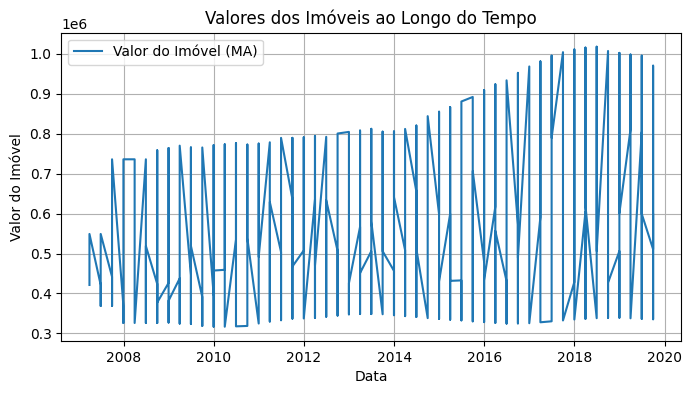

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(data['saledate'], data['MA'], label='Valor do Imóvel (MA)')
plt.title('Valores dos Imóveis ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Valor do Imóvel')
plt.grid(True)
plt.legend()

Dividir entre treinamento e teste

In [ ]:
train_data = data[data['saledate'] < '2018-01-01']
test_data = data[data['saledate'] >= '2018-01-01']

print('Tamanho do conjunto de treinamento:', train_data.shape)
print('Tamanho do conjunto de teste:', test_data.shape)

print(train_data.head())
print(test_data.head())

Tamanho do conjunto de treinamento: (298, 4)
Tamanho do conjunto de teste: (49, 4)
      saledate      MA   type  bedrooms
49  2007-03-31  421291  house         3
100 2007-03-31  548969  house         4
50  2007-06-30  421291  house         3
248 2007-06-30  368817   unit         2
101 2007-06-30  548969  house         4
      saledate       MA   type  bedrooms
340 2018-03-31   604293   unit         3
291 2018-03-31   427856   unit         2
193 2018-03-31  1015529  house         5
144 2018-03-31   836056  house         4
241 2018-03-31   336637   unit         1


2. Modelo base

In [ ]:
# Modelo Base: usar o valor do trimestre anterior como previsão
train_data['prev_base'] = train_data['MA'].shift(1)

# Remover valores NaN resultantes do shift no conjunto de treinamento
train_model_data = train_data.dropna(subset=['prev_base'])

# Aplicar o mesmo processo ao conjunto de teste
test_data['prev_base'] = test_data['MA'].shift(1)
test_model_data = test_data.dropna(subset=['prev_base'])

# Calcular o erro absoluto percentual médio para o modelo Base nos conjuntos de treino e teste
mse_train_base = mean_absolute_percentage_error(train_model_data['MA'], train_model_data['prev_base'])
mse_test_base = mean_absolute_percentage_error(test_model_data['MA'], test_model_data['prev_base'])

print(f'Erro Absoluto Percentual Médio para o Conjunto de Treinamento: {mse_train_base}')
print(f'Erro Absoluto Percentual Médio para o Conjunto de Teste: {mse_test_base}')

Erro Absoluto Percentual Médio para o Conjunto de Treinamento: 36.00421099852626
Erro Absoluto Percentual Médio para o Conjunto de Teste: 42.36909209259629


<ipython-input-105-20b7770d3cc8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['prev_base'] = train_data['MA'].shift(1)
<ipython-input-105-20b7770d3cc8>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['prev_base'] = test_data['MA'].shift(1)


3. Modelo sazonal

In [ ]:
# Modelo Sazonal: usar o valor do mesmo trimestre do ano anterior como previsão (shift de 4 trimestres)
train_data['prev_sazonal'] = train_data['MA'].shift(4)

# Remover valores NaN resultantes do shift no conjunto de treinamento
train_sazonal_model_data = train_data.dropna(subset=['prev_sazonal'])

# Aplicar o mesmo processo ao conjunto de teste
test_data['prev_sazonal'] = test_data['MA'].shift(4)
test_sazonal_model_data = test_data.dropna(subset=['prev_sazonal'])

# Calcular o erro absoluto percentual médio para o modelo Sazonal nos conjuntos de treino e teste
mse_train_sazonal = mean_absolute_percentage_error(train_sazonal_model_data['MA'], train_sazonal_model_data['prev_sazonal'])
mse_test_sazonal = mean_absolute_percentage_error(test_sazonal_model_data['MA'], test_sazonal_model_data['prev_sazonal'])

print(f'Erro Absoluto Percentual Médio para o Conjunto de Treinamento (Modelo Sazonal): {mse_train_sazonal}')
print(f'Erro Absoluto Percentual Médio para o Conjunto de Teste (Modelo Sazonal): {mse_test_sazonal}')

Erro Absoluto Percentual Médio para o Conjunto de Treinamento (Modelo Sazonal): 31.7755928954103
Erro Absoluto Percentual Médio para o Conjunto de Teste (Modelo Sazonal): 40.37973024256131


<ipython-input-106-62a4dbeaf40e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['prev_sazonal'] = train_data['MA'].shift(4)
<ipython-input-106-62a4dbeaf40e>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['prev_sazonal'] = test_data['MA'].shift(4)


4. Modelo de tendência

In [123]:
# Modelo de Tendência: calcular a média dos últimos 10 trimestres
window = 10

# Função para calcular a tendência considerando o valor anterior + mudança nos últimos 'n_periods'
def calculate_trend(data, n_periods):
    initial_value = data['MA'].shift(n_periods)  # Valor do período inicial (n períodos atrás)
    final_value = data['MA'].shift(1)  # Valor do período anterior
    trend = final_value + (final_value - initial_value) / window
    return trend

# Calcular a tendência para os dados de treinamento
train_data['prev_tendencia'] = calculate_trend(train_data, window)

# Remover valores NaN resultantes do cálculo no conjunto de treinamento
train_tendencia_model_data = train_data.dropna(subset=['prev_tendencia'])

# Aplicar o mesmo processo ao conjunto de teste
test_data['prev_tendencia'] = calculate_trend(test_data, window)
test_tendencia_model_data = test_data.dropna(subset=['prev_tendencia'])

# Calcular o erro absoluto percentual médio para o modelo de tendência nos conjuntos de treino e teste
mse_train_tendencia = mean_absolute_percentage_error(train_tendencia_model_data['MA'], train_tendencia_model_data['prev_tendencia'])
mse_test_tendencia = mean_absolute_percentage_error(test_tendencia_model_data['MA'], test_tendencia_model_data['prev_tendencia'])

print(f'Erro Absoluto Percentual Médio para o Conjunto de Treinamento (Modelo de Tendência): {mse_train_tendencia}')
print(f'Erro Absoluto Percentual Médio para o Conjunto de Teste (Modelo de Tendência): {mse_test_tendencia}')

Erro Absoluto Percentual Médio para o Conjunto de Treinamento (Modelo de Tendência): 38.02228176453649
Erro Absoluto Percentual Médio para o Conjunto de Teste (Modelo de Tendência): 44.19516254429618


<ipython-input-123-49afd24d3c3d>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['prev_tendencia'] = calculate_trend(train_data, window)
<ipython-input-123-49afd24d3c3d>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['prev_tendencia'] = calculate_trend(test_data, window)


5. Média móvel

In [ ]:
# Modelo de Média Móvel: calcular a média dos últimos 3 trimestres
train_data['prev_media_movel'] = train_data['MA'].rolling(window=3).mean()

# Remover valores NaN resultantes do cálculo da média móvel no conjunto de treinamento
train_media_movel_model_data = train_data.dropna(subset=['prev_media_movel'])

# Aplicar o mesmo processo ao conjunto de teste
test_data['prev_media_movel'] = test_data['MA'].rolling(window=3).mean()
test_media_movel_model_data = test_data.dropna(subset=['prev_media_movel'])

# Calcular o erro absoluto percentual médio para o modelo de Média Móvel nos conjuntos de treino e teste
mse_train_media_movel = mean_absolute_percentage_error(train_media_movel_model_data['MA'], train_media_movel_model_data['prev_media_movel'])
mse_test_media_movel = mean_absolute_percentage_error(test_media_movel_model_data['MA'], test_media_movel_model_data['prev_media_movel'])

print(f'Erro Absoluto Percentual Médio para o Conjunto de Treinamento (Modelo de Média Móvel): {mse_train_media_movel}')
print(f'Erro Absoluto Percentual Médio para o Conjunto de Teste (Modelo de Média Móvel): {mse_test_media_movel}')

Erro Absoluto Percentual Médio para o Conjunto de Treinamento (Modelo de Média Móvel): 20.30997189667045
Erro Absoluto Percentual Médio para o Conjunto de Teste (Modelo de Média Móvel): 25.811071747241844


<ipython-input-108-51c35614eeee>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['prev_media_movel'] = train_data['MA'].rolling(window=3).mean()
<ipython-input-108-51c35614eeee>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['prev_media_movel'] = test_data['MA'].rolling(window=3).mean()


5. Regressão linear

No caso dos imóveis, faz sentido pensar que temos acesso às propriedades do imóvel no instante de tempo atual. Assim, podemos utilizar essas informações. Vamos usar então as variáveis contemporâneas 'type' e 'bedrooms' e o valor do período anterior.

In [ ]:
# Codificar a variável categórica 'type' usando one-hot encoding
train_data_encoded = pd.get_dummies(train_data, columns=['type'], drop_first=True)
test_data_encoded = pd.get_dummies(test_data, columns=['type'], drop_first=True)

# Usar a coluna 'MA' anterior para prever o próximo valor de 'MA'
train_data_encoded['prev_value'] = train_data_encoded['MA'].shift(1)
test_data_encoded['prev_value'] = test_data_encoded['MA'].shift(1)

# Remover valores NaN resultantes do shift
train_data_encoded = train_data_encoded.dropna(subset=['prev_value'])
test_data_encoded = test_data_encoded.dropna(subset=['prev_value'])

# Selecionar as variáveis independentes (X) e a dependente (y) no conjunto de treino
X_train = train_data_encoded[['prev_value', 'bedrooms', 'type_unit']]
y_train = train_data_encoded['MA']

# Selecionar as variáveis independentes (X) e a dependente (y) no conjunto de teste
X_test = test_data_encoded[['prev_value', 'bedrooms', 'type_unit']]
y_test = test_data_encoded['MA']

# Treinar o modelo de regressão linear com as novas features
model_new = LinearRegression()
model_new.fit(X_train, y_train)

# Fazer previsões e calcular o erro no conjunto de teste
test_data_encoded['prev_regression_new'] = model_new.predict(X_test)
mse_regression_new = mean_absolute_percentage_error(y_test, test_data_encoded['prev_regression_new'])

print(f'Erro Absoluto Percentual Médio para a Regressão Linear: {mse_regression_new}')

Erro Absoluto Percentual Médio para a Regressão Linear: 13.359017914053753


<ipython-input-112-83a083a5c3eb>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data_encoded['prev_regression_new'] = model_new.predict(X_test)


## Exercício 2

O conjunto de dados abaixo apresenta os relatórios de queimadas no Brasil, entre 1998 e 2017.

https://www.kaggle.com/datasets/gustavomodelli/forest-fires-in-brazil

Vamos realizar duas tarefas: uma análise preliminar dos dados e uma previsão para o último ano da série (2017).

**Obs.:** O mês de março gera um problema de leitura, por causa do ç.

**1. Análise exploratória:**

*   Carregue os dados;
*   Leia a documentação e procure pensar sobre o problema: qual comportamento você espera encontrar nos dados?;
*   Gere quatro gráficos: i) o número de incêndios por período (mês-ano); ii) o número de incêndios por ano; iii) o número de incêndios por mês; iv) o número de incêndios por período, separado por estado;
*   Qual o pior ano da série? Quais estados apresentam os maiores picos de incêndios?


**2. Divisão do dataset:**

*   Use os valores até 2014 para treinamento e os anos seguintes (2015-17) como base de teste.

**3. Previsão:**

*   Utilize os cinco baselines estudados na aula anterior para prever os valores do conjunto teste: base, base com sazonalidade, tendência simples, média móvel e média móvel ponderada;




In [ ]:
df = pd.read_csv('amazon.csv')

df.head()

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01


In [ ]:
# Converter a data
df['date'] = pd.to_datetime(df['date'])

Text(0, 0.5, 'Número de Incêndios')

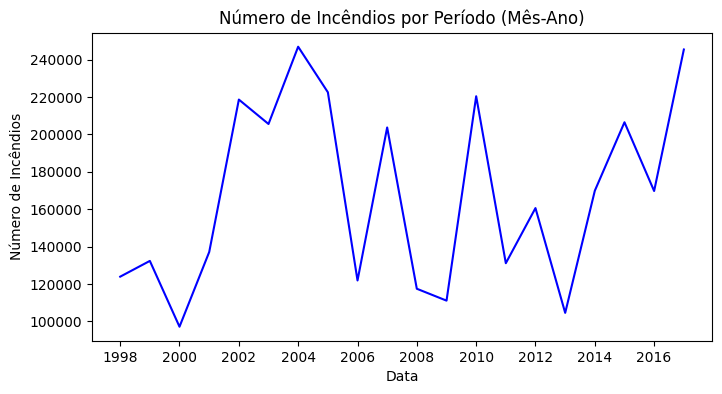

In [ ]:
# Análise 1 - Número de incêndios por período (mês-ano)
monthly_fires = df.groupby(['date']).agg({'number': 'sum'})

plt.figure(figsize=(8, 4))
plt.plot(monthly_fires.index, monthly_fires['number'], color='b')
plt.title('Número de Incêndios por Período (Mês-Ano)')
plt.xlabel('Data')
plt.ylabel('Número de Incêndios')

Text(0, 0.5, 'Número de Incêndios')

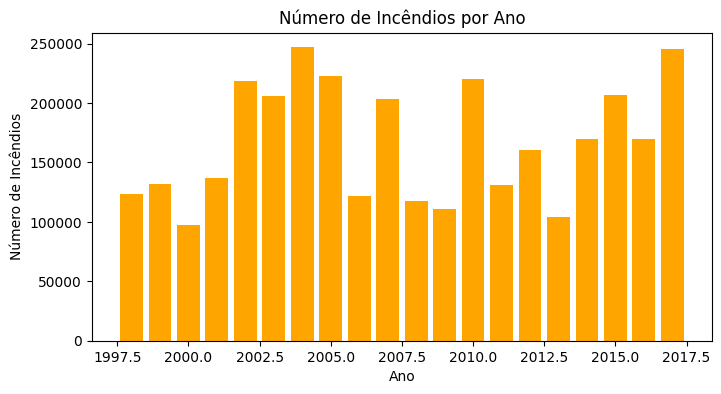

In [ ]:
# Análise 2 - Número de incêndios por ano
yearly_fires = df.groupby(['year']).agg({'number': 'sum'})

plt.figure(figsize=(8, 4))
plt.bar(yearly_fires.index, yearly_fires['number'], color='orange')
plt.title('Número de Incêndios por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Incêndios')

Text(0, 0.5, 'Número de Incêndios')

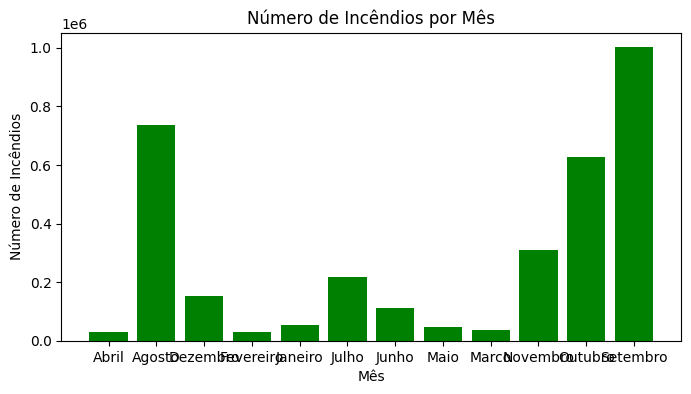

In [ ]:
# Análise 3 - Número de incêndios por mês
monthly_avg_fires = df.groupby(['month']).agg({'number': 'sum'})

plt.figure(figsize=(8, 4))
plt.bar(monthly_avg_fires.index, monthly_avg_fires['number'], color='green')
plt.title('Número de Incêndios por Mês')
plt.xlabel('Mês')
plt.ylabel('Número de Incêndios')

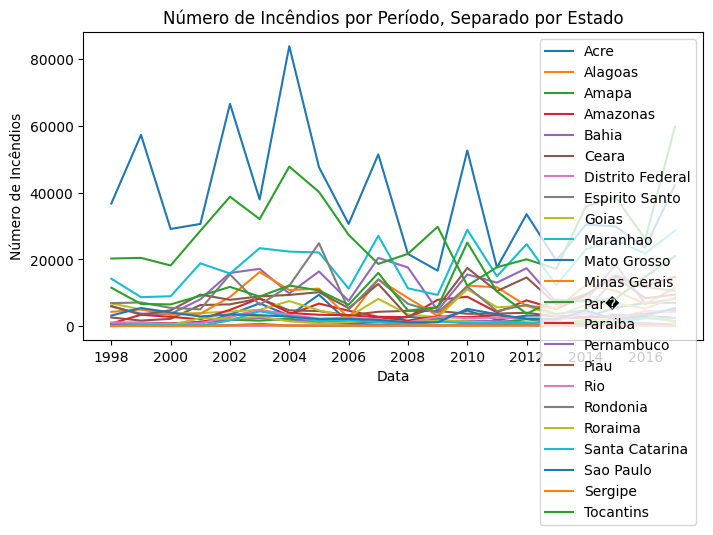

In [ ]:
# Análise 4 - Número de incêndios por período, separado por estado
fires_by_state_period = df.groupby(['state', 'date']).agg({'number': 'sum'})

plt.figure(figsize=(8, 4))
for state in df['state'].unique():
    state_data = fires_by_state_period.loc[state]
    plt.plot(state_data.index, state_data['number'], label=state)

plt.title('Número de Incêndios por Período, Separado por Estado')
plt.xlabel('Data')
plt.ylabel('Número de Incêndios')
plt.legend()

In [ ]:
# Determinar o pior ano e os estados com maiores picos de incêndios
worst_year = yearly_fires['number'].idxmax()
worst_year_fires = yearly_fires.loc[worst_year, 'number']
peak_states = fires_by_state_period.groupby('state')['number'].max().sort_values(ascending=False).head()

print(f'O pior ano da série é o ano {worst_year} com {worst_year_fires} incêndios.')
print('Os estados com maiores picos de incêndios são:')
for state, fires in peak_states.items():
    print(f'{state}: {fires} incêndios')

O pior ano da série é o ano 2004 com 246857.55 incêndios.
Os estados com maiores picos de incêndios são:
Mato Grosso: 83908.0 incêndios
Par�: 59771.0 incêndios
Maranhao: 28896.0 incêndios
Tocantins: 25069.0 incêndios
Rondonia: 24858.0 incêndios
